# Modèle 4 — MLP (Deep Learning)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.linear_model import Ridge
# Métriques sklearn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, mean_absolute_error,
    mean_squared_error, r2_score
)

RANDOM_STATE = 42

# Fixation complète de tous les seeds pour reproductibilité totale
import random
import os
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
os.environ['PYTHONHASHSEED']       = str(RANDOM_STATE)
os.environ['TF_DETERMINISTIC_OPS'] = '1'   # Opérations déterministes GPU/CPU

os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print(f"Imports OK")
print(f"   TensorFlow version : {tf.__version__}")

Imports OK
   TensorFlow version : 2.21.0


## Chargement des données preprocessées


In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

# Classification — données rééquilibrées par undersampling
X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# SMOTE
X_train_smote     = np.load('../data/processed/X_train_smote.npy')
y_train_clf_smote = np.load('../data/processed/y_train_clf_smote.npy')

# Labels originaux (pour régression)
y_train_clf = np.load('../data/processed/y_train_clf.npy')
y_test_clf  = np.load('../data/processed/y_test_clf.npy')
y_test_reg  = np.load('../data/processed/y_test_reg.npy')

feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

# Calcul du poids pour les classes déséquilibrées
print(f"Données chargées")
print(f"   X_train         : {X_train.shape} (original)")
print(f"   X_train_under   : {X_train_under.shape} (rééquilibré 50/50)")
print(f"   X_test          : {X_test.shape}")
print(f"   Churners train_under : {y_train_clf_under.sum()} ({y_train_clf_under.mean()*100:.1f}%)")
print(f"   Churners test        : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")

Données chargées
   X_train         : (8000, 50) (original)
   X_train_under   : (1634, 50) (rééquilibré 50/50)
   X_test          : (2000, 50)
   Churners train_under : 817 (50.0%)
   Churners test        : 204 (10.2%)


## Tâche 1 — Architecture du MLP Classification


In [3]:
# TÂCHE 1 — CLASSIFICATION MLP

def build_mlp_classifier(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        
        # Couche 1
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        
        # Couche 2
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        
        # Couche 3
        layers.Dense(32, activation='relu'),
        
        # Sortie
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 
                 keras.metrics.AUC(name='auc'),
                 keras.metrics.Recall(name='recall'),
                 keras.metrics.Precision(name='precision')]
    )
    return model

# Construction
mlp_clf = build_mlp_classifier(X_train_under.shape[1])
mlp_clf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=10,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# Entraînement
# Reset seed juste avant le fit pour garantir reproductibilité
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

history = mlp_clf.fit(
    X_train_under, y_train_clf_under,   # données équilibrées 50/50
    epochs=100,
    batch_size=64,                       # batch réduit (1638 samples)
    validation_split=0.2,
    # class_weight supprimé — données déjà équilibrées par undersampling
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\n Entraînement terminé !")
print(f"   Epochs effectuées : {len(history.history['loss'])}")

# ---- Entraînement SMOTE ----
print("\n=== Entraînement sur SMOTE ===")
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

mlp_clf_smote = build_mlp_classifier(X_train_smote.shape[1])
history_smote = mlp_clf_smote.fit(
    X_train_smote, y_train_clf_smote,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)
print("MLP SMOTE entraîné !")

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.5409 - auc: 0.5135 - loss: 0.7090 - precision: 0.3904 - recall: 0.4000 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 0.9627 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6236 - auc: 0.5522 - loss: 0.6580 - precision: 0.3750 - recall: 0.0061 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 0.9190 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6243 - auc: 0.6237 - loss: 0.6407 - precision: 0.4815 - recall: 0.0265 - val_accuracy: 0.0367 - val_auc: 0.0000e+00 - val_loss: 0.9165 - val_precision: 1.0000 - val_recall: 0.0367 - learning_rate: 0.0010
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6435 - auc: 0.6794 - loss: 0.6204 - precision: 0.6667 - recall: 0.0980 - val_accuracy: 0.1407 - val_auc

## Courbes d'apprentissage


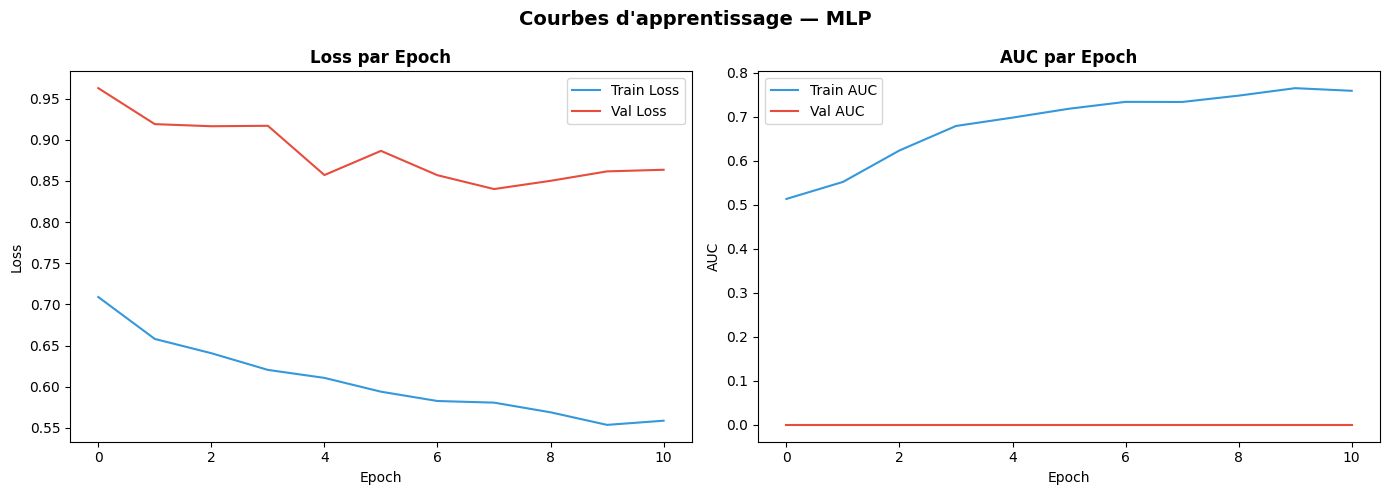

In [5]:
# COURBES D'APPRENTISSAGE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], 
             label='Train Loss', color='#3498db')
axes[0].plot(history.history['val_loss'], 
             label='Val Loss', color='#e74c3c')
axes[0].set_title('Loss par Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# AUC
axes[1].plot(history.history['auc'], 
             label='Train AUC', color='#3498db')
axes[1].plot(history.history['val_auc'], 
             label='Val AUC', color='#e74c3c')
axes[1].set_title('AUC par Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.suptitle('Courbes d\'apprentissage — MLP', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/mlp_learning_curves.png', dpi=150)
plt.show()

In [6]:
# ÉVALUATION CLASSIFICATION

y_proba_clf = mlp_clf.predict(X_test).flatten()

# Seuil optimal via courbe ROC
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test_clf, y_proba_clf)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Seuil optimal : {optimal_threshold:.4f}")

# Prédiction avec seuil ajusté
y_pred_clf = (y_proba_clf >= optimal_threshold).astype(int)

print(f"\nRésultats — MLP (Classification)")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_clf):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_clf):.4f}")

# ---- Évaluation SMOTE ----
y_proba_smote = mlp_clf_smote.predict(X_test).flatten()
fpr_s, tpr_s, thresholds_s = roc_curve(y_test_clf, y_proba_smote)
optimal_idx_s = np.argmax(tpr_s - fpr_s)
optimal_threshold_s = thresholds_s[optimal_idx_s]
y_pred_smote = (y_proba_smote >= optimal_threshold_s).astype(int)

print(f"\n=== MLP — SMOTE ===")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_smote):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_smote):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_smote):.4f}")

# Sélection du meilleur
f1_under = recall_score(y_test_clf, y_pred_clf)
f1_smote_val = recall_score(y_test_clf, y_pred_smote)
if f1_smote_val >= f1_under:
    mlp_clf_best = mlp_clf_smote
    y_pred_clf   = y_pred_smote
    y_proba_clf  = y_proba_smote
    best_technique = 'SMOTE'
else:
    mlp_clf_best = mlp_clf
    best_technique = 'Undersampling'
print(f"\n→ Meilleure technique : {best_technique} (Recall={max(f1_under, f1_smote_val):.4f})")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Seuil optimal : 0.3883

Résultats — MLP (Classification)
   Accuracy  : 0.6465
   Precision : 0.1412
   Recall    : 0.4853
   F1-Score  : 0.2188
   ROC-AUC   : 0.5850
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

=== MLP — SMOTE ===
   Accuracy  : 0.7445
   Precision : 0.2109
   Recall    : 0.5490
   F1-Score  : 0.3048
   ROC-AUC   : 0.7099

→ Meilleure technique : SMOTE (Recall=0.5490)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


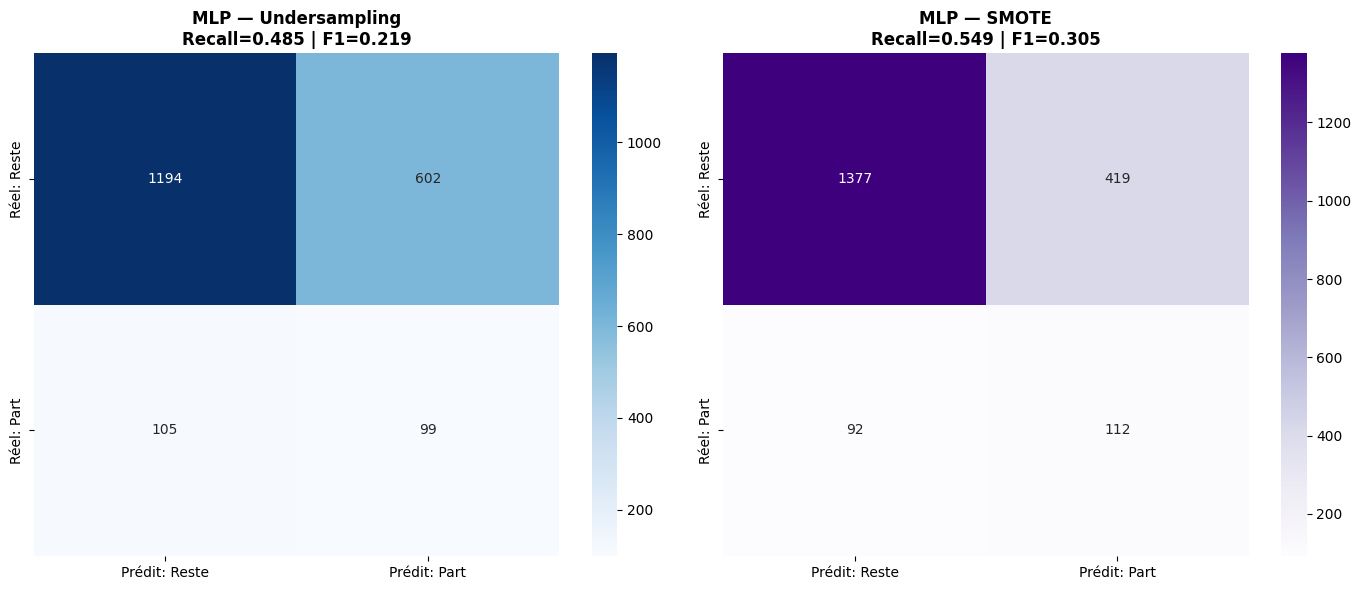

In [7]:
# MATRICE DE CONFUSION — Comparaison

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (y_pred, title, cmap) in zip(axes, [
    (y_pred_under if 'y_pred_under' in dir() else (mlp_clf.predict(X_test).flatten() >= optimal_threshold).astype(int),
     'MLP — Undersampling', 'Blues'),
    (y_pred_smote, 'MLP — SMOTE', 'Purples'),
]):
    cm_plot = confusion_matrix(y_test_clf, y_pred)
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Prédit: Reste', 'Prédit: Part'],
                yticklabels=['Réel: Reste', 'Réel: Part'], ax=ax)
    ax.set_title(f'{title}\nRecall={recall_score(y_test_clf, y_pred):.3f} | F1={f1_score(y_test_clf, y_pred):.3f}',
                 fontweight='bold')

plt.tight_layout()
plt.savefig('../results/mlp_confusion_matrix.png', dpi=150)
plt.show()

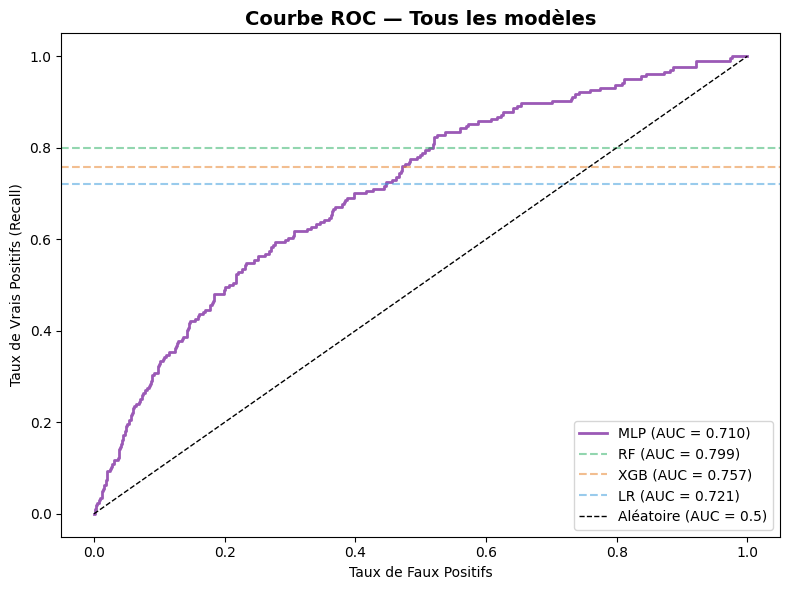

In [8]:
# COURBE ROC FINALE — Tous les modèles

fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
auc = roc_auc_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#9b59b6', linewidth=2,
         label=f'MLP (AUC = {auc:.3f})')
plt.axhline(y=0.7993, color='#27ae60', linestyle='--',
            alpha=0.5, label='RF (AUC = 0.799)')
plt.axhline(y=0.7570, color='#e67e22', linestyle='--',
            alpha=0.5, label='XGB (AUC = 0.757)')
plt.axhline(y=0.7212, color='#3498db', linestyle='--',
            alpha=0.5, label='LR (AUC = 0.721)')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC — Tous les modèles',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/mlp_roc_curve.png', dpi=150)
plt.show()

## Tâche 2 — Régression du Revenu à Risque


In [9]:
# ============================================================
# TÂCHE 2 — RÉGRESSION MLP
# ============================================================

# Charger les données spécifiques régression
X_train_reg     = np.load('../data/processed/X_train_reg.npy')       # churners uniquement
y_train_reg_log = np.load('../data/processed/y_train_reg_log.npy')   # log-transformé
y_test_reg      = np.load('../data/processed/y_test_reg.npy')        # valeurs réelles €

def build_mlp_regressor(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

mlp_reg = build_mlp_regressor(X_train_reg.shape[1])

early_stop_reg = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Entraînement sur churners uniquement avec y log-transformé
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

history_reg = mlp_reg.fit(
    X_train_reg, y_train_reg_log,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_reg],
    verbose=1
)

# Prédiction sur TOUS les clients du test
y_pred_reg_log = mlp_reg.predict(X_test).flatten()

# Transformation inverse log → euros réels
y_pred_reg = np.expm1(y_pred_reg_log)
y_pred_reg = np.maximum(y_pred_reg, 0)

# Évaluation sur les churners du test uniquement
churners_test_mask = y_test_reg > 0
mae  = mean_absolute_error(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask])
rmse = np.sqrt(mean_squared_error(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask]))
r2   = r2_score(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask])

print(f"\n Résultats — MLP Regression (churners uniquement)")
print(f"   MAE  : {mae:.2f} €")
print(f"   RMSE : {rmse:.2f} €")
print(f"   R²   : {r2:.4f}")

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 35.3459 - mae: 5.7613 - val_loss: 28.3331 - val_mae: 5.1341
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 24.3345 - mae: 4.6938 - val_loss: 18.0276 - val_mae: 3.9823
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 14.0814 - mae: 3.4118 - val_loss: 8.7988 - val_mae: 2.6391
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.3829 - mae: 2.1642 - val_loss: 3.2196 - val_mae: 1.4684
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1173 - mae: 1.4540 - val_loss: 2.4835 - val_mae: 1.2669
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.6664 - mae: 1.2895 - val_loss: 1.9096 - val_mae: 1.1061
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.0800 - mae: 1.1299 - val_loss: 1.4423 - val_mae: 0.9578
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.6897 - mae: 1.0506 - val_loss: 1.1903 - val_mae: 0.8667
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step -

In [10]:
# SAUVEGARDE

# Sauvegarde MLP au format keras
print(f'Sauvegarde du meilleur modèle : {best_technique}')
mlp_clf_best.save('../models/mlp_classification.keras')
mlp_reg.save('../models/mlp_regression.keras')

results_clf = {
    'model'    : 'MLP (' + best_technique + ')',
    'accuracy' : accuracy_score(y_test_clf, y_pred_clf),
    'precision': precision_score(y_test_clf, y_pred_clf),
    'recall'   : recall_score(y_test_clf, y_pred_clf),
    'f1'       : f1_score(y_test_clf, y_pred_clf),
    'roc_auc'  : roc_auc_score(y_test_clf, y_proba_clf)
}

results_reg = {
    'model': 'MLP Regression',
    'mae' : mae,
    'rmse': rmse,
    'r2'  : r2
}

pd.DataFrame([results_clf]).to_csv('../results/mlp_clf_results.csv', index=False)
pd.DataFrame([results_reg]).to_csv('../results/mlp_reg_results.csv', index=False)

print("Modèles sauvegardés dans ../models/")
print("Résultats sauvegardés dans ../results/")
print(f"\n Résumé Classification :")
for k, v in results_clf.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")

Sauvegarde du meilleur modèle : SMOTE
Modèles sauvegardés dans ../models/
Résultats sauvegardés dans ../results/

 Résumé Classification :
   accuracy   : 0.7445
   precision  : 0.2109
   recall     : 0.5490
   f1         : 0.3048
   roc_auc    : 0.7099


## Synthèse — MLP (Deep Learning)
